# Checkout Flow Redesign — A/B Test Analysis

**Experiment:** New single-page checkout flow vs. existing multi-step checkout
**Owner:** Data Science
**Status:** Analysis complete — see decision at the end

This notebook performs the full pre-registered analysis: sample ratio mismatch (SRM)
check, primary metric test, guardrail tests with multiple-comparisons correction,
and a novelty-effect check. All metrics, thresholds, and the decision rule were
fixed in `reports/design_doc.md` **before** this data was analyzed.


In [1]:
import sys, json
sys.path.append('../scripts')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from analysis import (load_data, srm_check, test_primary_metric, test_guardrail_aov,
                       test_guardrail_rate, novelty_check, apply_correction, decide_ship)

plt.rcParams['figure.figsize'] = (9, 4)
df = load_data(srm_demo=False)
df.head()


,session_id,day,arm,purchased,order_value,refunded,support_contact
0,1,1,control,0,NaN,0,0
1,2,1,treatment,0,NaN,0,0
2,3,1,treatment,0,NaN,0,0
3,4,1,control,0,NaN,0,0
4,5,1,treatment,0,NaN,0,0


## 1. Data overview

In [2]:
print(f"Rows: {len(df):,}")
print(df.groupby('arm').size())
df.describe(include='all')


Rows: 102,710
arm
control      51360
treatment    51350
dtype: int64


,session_id,day,arm,purchased,order_value,refunded,support_contact
count,102710.000000,102710.000000,102710,102710.000000,6542.000000,102710.000000,102710.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN
top,NaN,NaN,control,NaN,NaN,NaN,NaN
freq,NaN,NaN,51360,NaN,NaN,NaN,NaN
mean,51355.500000,14.514020,NaN,0.063694,68.422817,0.002609,0.020563
std,29649.967411,8.063164,NaN,0.244208,23.680091,0.051015,0.141916
min,1.000000,1.000000,NaN,0.000000,5.000000,0.000000,0.000000
25%,25678.250000,8.000000,NaN,0.000000,52.440000,0.000000,0.000000
50%,51355.500000,15.000000,NaN,0.000000,68.425000,0.000000,0.000000
75%,77032.750000,21.000000,NaN,0.000000,84.490000,0.000000,0.000000


## 2. Sample Ratio Mismatch (SRM) check

Before trusting *any* downstream metric, we confirm the observed traffic split
matches the intended 50/50 randomization. A significant deviation (chi-square
goodness-of-fit p < 0.001) indicates a logging, bucketing, or filtering bug that
invalidates the comparison — regardless of how good the primary metric looks.


In [3]:
srm = srm_check(df)
srm


{'n_control': 51360,
 'n_treatment': 51350,
 'ratio_treatment': np.float64(0.5),
 'chi2_statistic': np.float64(0.001),
 'p_value': np.float64(0.9751078030311983),
 'srm_detected': False,
 'threshold': 0.001}

In [4]:
assert not srm['srm_detected'], "SRM detected — STOP. Do not proceed to metric analysis until this is resolved."
print("SRM check passed. Proceeding with metric analysis.")


SRM check passed. Proceeding with metric analysis.


## 3. Primary metric: Checkout conversion rate

Pre-registered as the single primary decision metric (design_doc.md, Section 2).
Two-proportion z-test, tested at the family-wise alpha after correction (Section 5).


In [5]:
primary = test_primary_metric(df)
primary


{'metric': 'checkout_conversion_rate',
 'control_rate': np.float64(0.06092),
 'treatment_rate': np.float64(0.06647),
 'absolute_diff': np.float64(0.00554),
 'relative_diff_pct': np.float64(9.098),
 'ci_95_absolute': [np.float64(0.00256), np.float64(0.00853)],
 'z_stat': np.float64(3.6369),
 'p_value': np.float64(0.0002759775125614475)}

## 4. Guardrail metrics

Three guardrails were pre-registered:
1. **Average order value (AOV)** — redesign should not reduce basket size
2. **14-day refund rate** — redesign should not induce impulse purchases that get refunded
3. **7-day support contact rate** — redesign should not confuse users into contacting support


In [6]:
guardrail_aov = test_guardrail_aov(df)
guardrail_refund = test_guardrail_rate(df, 'refunded', 'refund_rate_14d')
guardrail_support = test_guardrail_rate(df, 'support_contact', 'support_contact_rate_7d')
guardrail_aov, guardrail_refund, guardrail_support


({'metric': 'average_order_value',
  'control_mean': np.float64(68.23),
  'treatment_mean': np.float64(68.6),
  'absolute_diff': np.float64(0.37),
  'relative_diff_pct': np.float64(0.536),
  't_stat': np.float64(0.6238),
  'p_value': np.float64(0.5327733405256755),
  'guardrail_rule': 'flag if treatment mean drops more than 2% relative'},
 {'metric': 'refund_rate_14d',
  'control_rate': np.float64(0.00276),
  'treatment_rate': np.float64(0.00245),
  'absolute_diff_pp': np.float64(-0.031),
  'z_stat': np.float64(-0.977),
  'p_value': np.float64(0.3285507353854892)},
 {'metric': 'support_contact_rate_7d',
  'control_rate': np.float64(0.0184),
  'treatment_rate': np.float64(0.02273),
  'absolute_diff_pp': np.float64(0.433),
  'z_stat': np.float64(4.8856),
  'p_value': np.float64(1.0310326668134327e-06)})

## 5. Multiple comparisons correction

We are formally testing 4 hypotheses (1 primary + 3 guardrails) against the same
experiment. Testing each at raw alpha = 0.05 would inflate the family-wise false
positive rate to roughly 1 - 0.95^4 ≈ 18.5%. We apply **Holm-Bonferroni**
correction (more powerful than plain Bonferroni, still strongly controls family-wise
error) across the family, at a target family-wise alpha of 0.05.


In [7]:
family = [primary, guardrail_aov, guardrail_refund, guardrail_support]
family = apply_correction(family)
pd.DataFrame(family)[['metric', 'p_value', 'p_value_holm_adjusted', 'significant_after_correction']]


,metric,p_value,p_value_holm_adjusted,significant_after_correction
0,checkout_conversion_rate,0.000276,0.000828,True
1,average_order_value,0.532773,0.657101,False
2,refund_rate_14d,0.328551,0.657101,False
3,support_contact_rate_7d,0.000001,0.000004,True


## 6. Novelty effect check

Treatment effects sometimes look larger in the first days of an experiment purely
because early adopters/curious users behave differently, or because of a
"newness" reaction that fades. We compare the relative lift in the first 10 days
against the remaining days. This is a diagnostic check, not a formal hypothesis
test — day-level sample sizes are small (~1,850 sessions/arm/day), so day-to-day
noise is expected to be large relative to any true novelty signal.


In [8]:
novelty = novelty_check(df)
print(f"Early window (days 1-10) relative lift: {novelty['early_relative_lift_pct']}%")
print(f"Late window (days 11-28) relative lift:  {novelty['late_relative_lift_pct']}%")
print(f"Novelty gap: {novelty['novelty_gap_pp']} pp")


Early window (days 1-10) relative lift: 4.92%
Late window (days 11-28) relative lift:  11.53%
Novelty gap: -6.61 pp


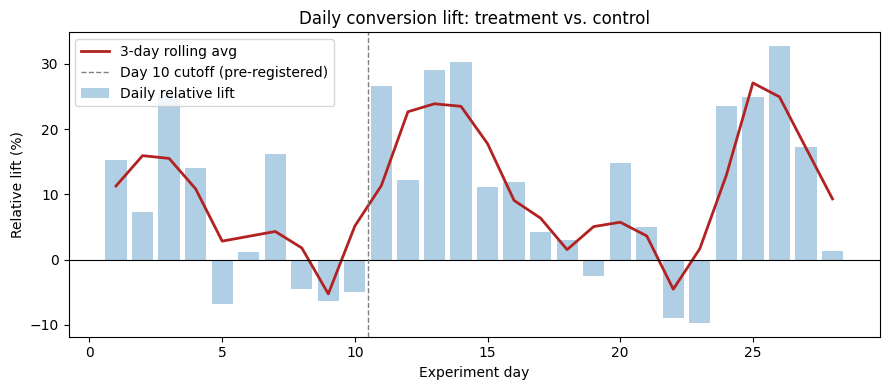

In [9]:
daily = pd.Series(novelty['daily_lift_series']).astype(float)
smoothed = pd.Series(novelty['daily_lift_series_3d_smoothed']).astype(float)
daily.index = daily.index.astype(int)
smoothed.index = smoothed.index.astype(int)

fig, ax = plt.subplots()
ax.bar(daily.index, daily.values * 100, alpha=0.35, label='Daily relative lift')
ax.plot(smoothed.index, smoothed.values * 100, color='firebrick', linewidth=2, label='3-day rolling avg')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(10.5, color='gray', linestyle='--', linewidth=1, label='Day 10 cutoff (pre-registered)')
ax.set_xlabel('Experiment day')
ax.set_ylabel('Relative lift (%)')
ax.set_title('Daily conversion lift: treatment vs. control')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/daily_lift.png', dpi=140)
plt.show()


**Interpretation:** the day-level lift series is noisy, and the early-window
average (days 1-10) is *not* higher than the late-window average — if anything the
opposite. Given the small per-day sample size relative to the effect size, this is
consistent with sampling noise rather than a genuine novelty or fatigue pattern.
**We do not claim a novelty effect here** — the check did not find convincing
evidence either way, and we report that honestly rather than fitting a story to
noisy data.


## 7. Visualizing the primary result


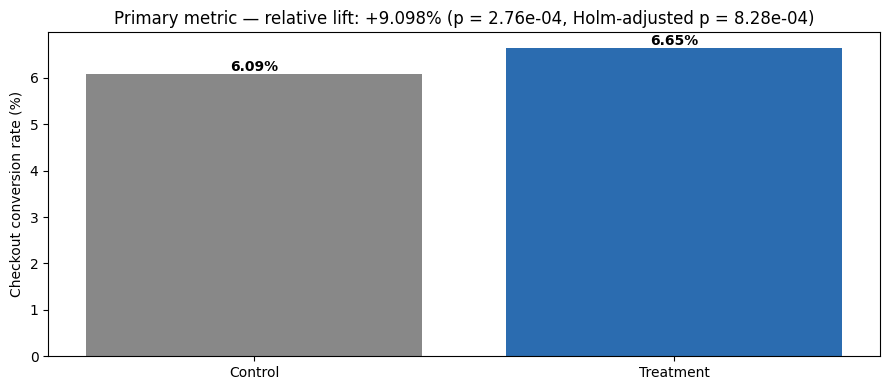

In [10]:
fig, ax = plt.subplots()
rates = [primary['control_rate'] * 100, primary['treatment_rate'] * 100]
bars = ax.bar(['Control', 'Treatment'], rates, color=['#888888', '#2b6cb0'])
for b, r in zip(bars, rates):
    ax.text(b.get_x() + b.get_width()/2, r + 0.05, f'{r:.2f}%', ha='center', fontweight='bold')
ax.set_ylabel('Checkout conversion rate (%)')
ax.set_title(f"Primary metric — relative lift: +{primary['relative_diff_pct']}% "
             f"(p = {primary['p_value']:.2e}, Holm-adjusted p = {primary['p_value_holm_adjusted']:.2e})")
plt.tight_layout()
plt.savefig('../reports/primary_metric.png', dpi=140)
plt.show()


## 8. Ship / no-ship decision

Applied mechanically from the pre-registered rule in `design_doc.md` Section 5 —
no post-hoc judgment calls.


In [11]:
decision = decide_ship(primary, [guardrail_aov, guardrail_refund, guardrail_support])
decision


{'decision': 'HOLD / DO NOT SHIP AS-IS',
 'reasons': ['Guardrail violated: support_contact_rate_7d shows a significant degradation in the treatment arm after correction.']}

## 9. Summary table for stakeholders


In [12]:
summary = pd.DataFrame([
    {'Metric': 'Checkout conversion rate (primary)', 'Control': f"{primary['control_rate']*100:.2f}%",
     'Treatment': f"{primary['treatment_rate']*100:.2f}%", 'Rel. change': f"+{primary['relative_diff_pct']}%",
     'Holm-adj. p': f"{primary['p_value_holm_adjusted']:.4f}", 'Significant?': primary['significant_after_correction']},
    {'Metric': 'Average order value (guardrail)', 'Control': f"${guardrail_aov['control_mean']:.2f}",
     'Treatment': f"${guardrail_aov['treatment_mean']:.2f}", 'Rel. change': f"{guardrail_aov['relative_diff_pct']:+.2f}%",
     'Holm-adj. p': f"{guardrail_aov['p_value_holm_adjusted']:.4f}", 'Significant?': guardrail_aov['significant_after_correction']},
    {'Metric': '14-day refund rate (guardrail)', 'Control': f"{guardrail_refund['control_rate']*100:.2f}%",
     'Treatment': f"{guardrail_refund['treatment_rate']*100:.2f}%", 'Rel. change': f"{guardrail_refund['absolute_diff_pp']:+.3f} pp",
     'Holm-adj. p': f"{guardrail_refund['p_value_holm_adjusted']:.4f}", 'Significant?': guardrail_refund['significant_after_correction']},
    {'Metric': '7-day support contact rate (guardrail)', 'Control': f"{guardrail_support['control_rate']*100:.2f}%",
     'Treatment': f"{guardrail_support['treatment_rate']*100:.2f}%", 'Rel. change': f"{guardrail_support['absolute_diff_pp']:+.3f} pp",
     'Holm-adj. p': f"{guardrail_support['p_value_holm_adjusted']:.4f}", 'Significant?': guardrail_support['significant_after_correction']},
])
summary


,Metric,Control,Treatment,Rel. change,Holm-adj. p,Significant?
0,Checkout conversion rate (primary),6.09%,6.65%,+9.098%,0.0008,True
1,Average order value (guardrail),$68.23,$68.60,+0.54%,0.6571,False
2,14-day refund rate (guardrail),0.28%,0.24%,-0.031 pp,0.6571,False
3,7-day support contact rate (guardrail),1.84%,2.27%,+0.433 pp,0.0000,True


## 10. Conclusion

The primary metric (checkout conversion rate) improved by **+9.1% relative**
and remains significant after Holm-Bonferroni correction. However, the
**7-day support contact rate guardrail** also moved significantly — support
contacts increased by roughly 0.43 percentage points in the treatment arm.
Per the pre-registered decision rule, **any significant guardrail degradation
blocks shipping**, regardless of how strong the primary result is.

**Decision: HOLD — do not ship as-is.** Recommended next step: work with the
support/CX team to identify *why* the new checkout flow is generating more
contacts (likely candidates: a confusing new field, unclear error states) before
re-testing a revised version. See `reports/executive_summary.md` for the
stakeholder-facing version of this conclusion.
